In [1]:
import pandas as pd

In [2]:
ssim_df = pd.read_csv('ssim.csv')
ssim_df

,category,content,SSIM parameters set 1,SSIM parameters set 2,SSIM parameters set 3,SSIM parameters set 4,SSIM parameters set 5
0,landscape,beaulieu,0.209986,0.054180,0.022443,0.153979,0.169131
1,landscape,beaulieu,0.214029,0.080033,0.025743,0.157171,0.334289
2,landscape,beaulieu,0.303134,0.172214,0.028252,0.266713,0.335573
3,still-life,skull,0.101914,0.051823,0.015587,0.091950,0.429772
4,still-life,skull,0.305680,0.189936,0.020415,0.297561,0.344851
5,still-life,skull,0.316816,0.195207,0.023217,0.297387,0.343552
6,portrait,girl,0.415137,0.260297,0.034836,0.411860,0.462338
7,portrait,girl,0.295497,0.136942,0.031002,0.328436,0.339268
8,portrait,girl,0.230094,0.102864,0.029521,0.216930,0.219434
9,portrait,man,0.235351,0.102899,0.027693,0.179743,0.241078


In [3]:
ssim_df['ssim1_normalized'] = ssim_df['SSIM parameters set 1'] / ssim_df['SSIM parameters set 1'].mean() - 1
ssim_df

,category,content,SSIM parameters set 1,SSIM parameters set 2,SSIM parameters set 3,SSIM parameters set 4,SSIM parameters set 5,ssim1_normalized
0,landscape,beaulieu,0.209986,0.054180,0.022443,0.153979,0.169131,-0.248960
1,landscape,beaulieu,0.214029,0.080033,0.025743,0.157171,0.334289,-0.234500
2,landscape,beaulieu,0.303134,0.172214,0.028252,0.266713,0.335573,0.084196
3,still-life,skull,0.101914,0.051823,0.015587,0.091950,0.429772,-0.635492
4,still-life,skull,0.305680,0.189936,0.020415,0.297561,0.344851,0.093303
5,still-life,skull,0.316816,0.195207,0.023217,0.297387,0.343552,0.133132
6,portrait,girl,0.415137,0.260297,0.034836,0.411860,0.462338,0.484789
7,portrait,girl,0.295497,0.136942,0.031002,0.328436,0.339268,0.056881
8,portrait,girl,0.230094,0.102864,0.029521,0.216930,0.219434,-0.177042
9,portrait,man,0.235351,0.102899,0.027693,0.179743,0.241078,-0.158237


In [4]:
ssim_df['ssim2_normalized'] = ssim_df['SSIM parameters set 2'] / ssim_df['SSIM parameters set 2'].mean() - 1
ssim_df['ssim3_normalized'] = ssim_df['SSIM parameters set 3'] / ssim_df['SSIM parameters set 3'].mean() - 1
ssim_df['ssim4_normalized'] = ssim_df['SSIM parameters set 4'] / ssim_df['SSIM parameters set 4'].mean() - 1
ssim_df['ssim5_normalized'] = ssim_df['SSIM parameters set 5'] / ssim_df['SSIM parameters set 5'].mean() - 1

In [5]:
ssim_df.head(5)

,category,content,SSIM parameters set 1,SSIM parameters set 2,SSIM parameters set 3,SSIM parameters set 4,SSIM parameters set 5,ssim1_normalized,ssim2_normalized,ssim3_normalized,ssim4_normalized,ssim5_normalized
0,landscape,beaulieu,0.209986,0.054180,0.022443,0.153979,0.169131,-0.248960,-0.633042,-0.175944,-0.422305,-0.520199
1,landscape,beaulieu,0.214029,0.080033,0.025743,0.157171,0.334289,-0.234500,-0.457941,-0.054799,-0.410328,-0.051670
2,landscape,beaulieu,0.303134,0.172214,0.028252,0.266713,0.335573,0.084196,0.166388,0.037346,0.000649,-0.048027
3,still-life,skull,0.101914,0.051823,0.015587,0.091950,0.429772,-0.635492,-0.649009,-0.427709,-0.655024,0.219200
4,still-life,skull,0.305680,0.189936,0.020415,0.297561,0.344851,0.093303,0.286421,-0.250405,0.116385,-0.021708


In [6]:
norm_cols = [
    "ssim1_normalized",
    "ssim2_normalized",
    "ssim3_normalized",
    "ssim4_normalized",
    "ssim5_normalized"
]

df_flat = ssim_df.melt(
    id_vars="category",
    value_vars=norm_cols,
    var_name="experiment",
    value_name="normalized_value"
)

In [7]:
df_flat

,category,experiment,normalized_value
0,landscape,ssim1_normalized,-0.248960
1,landscape,ssim1_normalized,-0.234500
2,landscape,ssim1_normalized,0.084196
3,still-life,ssim1_normalized,-0.635492
4,still-life,ssim1_normalized,0.093303
...,...,...,...
130,portrait,ssim5_normalized,0.262534
131,portrait,ssim5_normalized,0.441463
132,still-life,ssim5_normalized,-0.345955
133,still-life,ssim5_normalized,-0.374719


In [8]:
df_rq1 = (df_flat.groupby("category")["normalized_value"]
          .agg(["mean", "std", "median", "count"]))
df_rq1

,mean,std,median,count
category,,,,
landscape,-0.083616,0.463978,-0.175944,45
portrait,0.151298,0.333804,0.138285,45
still-life,-0.067682,0.392844,-0.121102,45


In [9]:
df_flat.groupby('category').describe()

normalized_value                                                    \
                      count      mean       std       min       25%       50%   
category                                                                        
landscape              45.0 -0.083616  0.463978 -0.732846 -0.417608 -0.175944   
portrait               45.0  0.151298  0.333804 -0.377497 -0.086174  0.138285   
still-life             45.0 -0.067682  0.392844 -0.655024 -0.374719 -0.121102   

                                
                 75%       max  
category                        
landscape   0.166262  1.284404  
portrait    0.440785  0.868058  
still-life  0.212286  1.153592

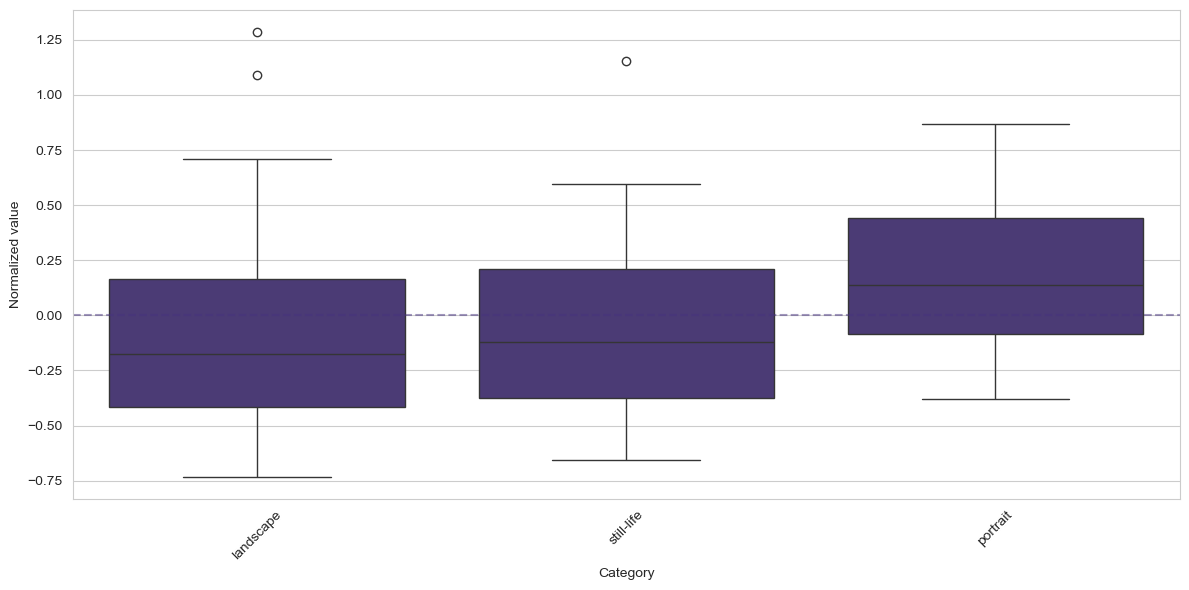

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_palette("viridis")

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_flat,
    x="category",
    y="normalized_value"
)

plt.axhline(0, linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.ylabel("Normalized value")
plt.xlabel("Category")
plt.tight_layout()
plt.savefig("category_results.png", dpi=300, bbox_inches="tight")
plt.show()

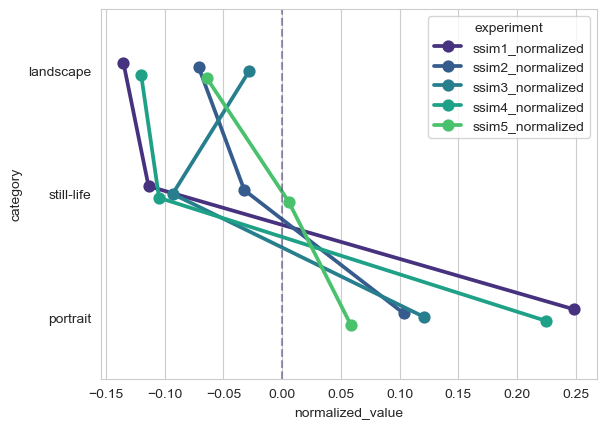

In [11]:
sns.pointplot(
    data=df_flat,
    x="normalized_value",
    y="category",
    hue="experiment",
    errorbar=None,
    dodge=True
)

plt.savefig("category_exp_results.png", dpi=300, bbox_inches="tight")
plt.axvline(0, linestyle="--", alpha=0.5)